---
title: "Intro Exercise. Explore GWAS Summary Statistics"
format:
  html:
    toc: true
    toc-depth: 3
    number-sections: true
---

# Overview

This notebook turns the original exploration script into a guided practical. You will load a large GWAS summary-statistics table, inspect its structure, apply simple quality-control filters, and generate the standard first-pass plots used in downstream interpretation.

::: {.callout-note}
## Learning goals
By the end of this notebook, you should be able to:
- describe the key columns in a GWAS summary-statistics file
- justify basic INFO and minor-allele-frequency filtering
- interpret Manhattan, QQ, and p-value distribution plots
- connect SNP-level results to later gene and pathway analyses
:::

::: {.callout-tip}
## Before you run anything
This notebook assumes you are running from the `repo/notebooks` directory. The ADHD summary-statistics file should be available at `input/ADHD2022_iPSYCH_deCODE_PGC.meta.gz`.
:::

::: {.callout-note}
## Study Questions
Use these questions to frame the analysis before you start:

1. Which columns are essential if you want to run gene-level analyses later?
2. Why are INFO and MAF filters usually applied before visualisation or downstream modelling?
3. What would you expect a healthy null-like p-value distribution to look like?
4. Why can a very large GWAS show some QQ-plot inflation even when the analysis is not obviously flawed?
:::

In [1]:
pacman::p_load(vroom, dplyr, ggplot2, scales, qqman)

sumstats_path <- "input/ADHD2022_iPSYCH_deCODE_PGC.meta.gz"
figures_dir <- "output/figures"
dir.create(figures_dir, showWarnings = FALSE, recursive = TRUE)

# What is in a GWAS summary-statistics file?

Each row represents one tested variant. The file does not contain individual-level genotype data; instead, it stores per-variant summaries such as association strength, uncertainty, allele frequency, and genomic position.

::: {.callout-important}
## Column guide
Typical columns in this dataset include:
- `CHR`: chromosome number
- `SNP`: variant identifier
- `BP`: base-pair position
- `A1` and `A2`: the two alleles
- `FRQ_A_38691`: frequency of the effect allele in cases
- `INFO`: imputation quality
- `OR`: odds ratio
- `SE`: standard error of the effect estimate
- `P`: p-value
- `Nca` and `Nco`: case and control counts
:::

In [2]:
cat("Loading GWAS summary statistics...\n")
sumstats <- vroom(sumstats_path, show_col_types = FALSE)
cat(sprintf("Loaded %s SNPs and %d columns.\n", format(nrow(sumstats), big.mark = ","), ncol(sumstats)))

head(sumstats)

Loading GWAS summary statistics...
Loaded 6,774,224 SNPs and 14 columns.


CHR,SNP,BP,A1,A2,FRQ_A_38691,FRQ_U_186843,INFO,OR,SE,P,Direction,Nca,Nco
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<dbl>,<dbl>
8,rs62513865,101592213,C,T,0.925,0.937,0.981,0.99631,0.0175,0.8325,+---+++0-++-+,38691,186843
8,rs79643588,106973048,G,A,0.910,0.917,1.000,1.00411,0.0159,0.7967,++--++-+-+-++,38691,186843
8,rs17396518,108690829,T,G,0.561,0.577,0.998,0.99611,0.0096,0.6876,--++-++??-+--,37367,184388
8,rs983166,108681675,A,C,0.570,0.586,0.996,0.99491,0.0096,0.5956,--++-++++-+--,38691,186843
8,rs28842593,103044620,T,C,0.839,0.836,0.982,0.98314,0.0135,0.2081,----++0+??--+,37504,184525
8,rs7014597,104152280,G,C,0.824,0.824,0.997,0.99950,0.0122,0.9679,+-++-+++++---,38691,186843


In [3]:
glimpse(sumstats)

Rows: 6,774,224
Columns: 14
$ CHR          <dbl> 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, 8, …
$ SNP          <chr> "rs62513865", "rs79643588", "rs17396518", "rs983166", "rs…
$ BP           <dbl> 101592213, 106973048, 108690829, 108681675, 103044620, 10…
$ A1           <chr> "C", "G", "T", "A", "T", "G", "T", "A", "A", "C", "G", "C…
$ A2           <chr> "T", "A", "G", "C", "C", "C", "C", "C", "T", "T", "A", "T…
$ FRQ_A_38691  <dbl> 0.925, 0.910, 0.561, 0.570, 0.839, 0.824, 0.841, 0.783, 0…
$ FRQ_U_186843 <dbl> 0.937, 0.917, 0.577, 0.586, 0.836, 0.824, 0.833, 0.790, 0…
$ INFO         <dbl> 0.981, 1.000, 0.998, 0.996, 0.982, 0.997, 0.997, 1.000, 0…
$ OR           <dbl> 0.99631, 1.00411, 0.99611, 0.99491, 0.98314, 0.99950, 0.9…
$ SE           <dbl> 0.0175, 0.0159, 0.0096, 0.0096, 0.0135, 0.0122, 0.0128, 0…
$ P            <dbl> 0.832500, 0.796700, 0.687600, 0.595600, 0.208100, 0.96790…
$ Direction    <chr> "+---+++0-++-+", "++--++-+-+-++", "--++-++??-+--", "--++-…
$ Nca       

# Basic structure checks

A first pass should answer three questions: how many variants are present, how they are distributed across chromosomes, and what the study sample size was. These checks catch obvious file-format problems early.

**Question for students:** if one chromosome had dramatically fewer variants than expected, what technical or biological explanations would you consider first?

In [4]:
snps_per_chr <- sumstats %>%
  count(CHR, name = "n_SNPs") %>%
  arrange(CHR)

n_cases <- sumstats$Nca[1]
n_controls <- sumstats$Nco[1]

snps_per_chr

CHR,n_SNPs
<dbl>,<int>
1,522784
2,581259
3,494157
4,500139
5,447115
6,464544
7,396727
8,385938
9,289399


In [5]:
cat(sprintf("Cases: %s\nControls: %s\nTotal N: %s\n",
            format(n_cases, big.mark = ","),
            format(n_controls, big.mark = ","),
            format(n_cases + n_controls, big.mark = ",")))

Cases: 38,691
Controls: 186,843
Total N: 225,534


# Quality control filters

This practical uses two simple filters:
- `INFO >= 0.8` to keep well-imputed variants
- `MAF >= 0.01` to remove very rare variants with unstable estimates

::: {.callout-warning}
These are teaching defaults, not universal rules. The right thresholds depend on study design, imputation quality, ancestry composition, and downstream method assumptions.
:::

**Question for students:** what do you lose, scientifically, when you remove low-frequency variants? What do you gain?

In [6]:
sumstats <- sumstats %>%
  mutate(MAF = pmin(FRQ_A_38691, 1 - FRQ_A_38691))

sumstats_qc <- sumstats %>%
  filter(INFO >= 0.8, MAF >= 0.01)

n_removed_info <- nrow(sumstats) - nrow(filter(sumstats, INFO >= 0.8))
n_removed_maf <- nrow(sumstats) - nrow(filter(sumstats, MAF >= 0.01))

qc_summary <- tibble(
  metric = c("Total SNPs before QC", "Removed: INFO < 0.8", "Removed: MAF < 0.01", "SNPs after QC"),
  value = c(nrow(sumstats), n_removed_info, n_removed_maf, nrow(sumstats_qc))
)

qc_summary

metric,value
<chr>,<int>
Total SNPs before QC,6774224
Removed: INFO < 0.8,0
Removed: MAF < 0.01,99
SNPs after QC,6774125


In [7]:
sumstats_qc %>%
  select(P, OR, SE, INFO, MAF) %>%
  summary()

       P                OR               SE               INFO       
 Min.   :0.0000   Min.   :0.8127   Min.   :0.00800   Min.   :0.8020  
 1st Qu.:0.1826   1st Qu.:0.9884   1st Qu.:0.01030   1st Qu.:0.9870  
 Median :0.4381   Median :0.9999   Median :0.01340   Median :0.9950  
 Mean   :0.4549   Mean   :1.0001   Mean   :0.01776   Mean   :0.9893  
 3rd Qu.:0.7159   3rd Qu.:1.0114   3rd Qu.:0.02180   3rd Qu.:0.9980  
 Max.   :1.0000   Max.   :1.3148   Max.   :0.08480   Max.   :1.0200  
      MAF        
 Min.   :0.0100  
 1st Qu.:0.0520  
 Median :0.1490  
 Mean   :0.1864  
 3rd Qu.:0.3050  
 Max.   :0.5000  

# Genomic inflation

The genomic inflation factor $\lambda$ compares the observed median association statistic with the value expected under the null. Values near 1 suggest little global inflation. In large highly polygenic studies, modest inflation can reflect real signal rather than poor calibration.

$$
\lambda = \frac{\mathrm{median}(\chi^2_{obs})}{\chi^2_{0.5, df=1}}
$$

:::{.callout-note}
**Question:** why is a rescaled measure such as $\lambda_{1000}$ useful when comparing studies with very different sample sizes?
:::

In [8]:
chisq_obs <- qchisq(1 - sumstats_qc$P, df = 1)
lambda_gc <- median(chisq_obs, na.rm = TRUE) / qchisq(0.5, df = 1)
N_total <- n_cases + n_controls
lambda1000 <- 1 + (lambda_gc - 1) * (1000 / N_total)

tibble(metric = c("lambda_GC", "lambda_1000"), value = c(lambda_gc, lambda1000))

metric,value
<chr>,<dbl>
lambda_GC,1.321622
lambda_1000,1.001426


# Genome-wide significant hits

The conventional genome-wide threshold is `5e-8`. This is a rough Bonferroni-style standard for the large number of common-variant tests performed across the genome.

::: {.callout-note}
Finding significant SNPs is only the start. The rest of this course pipeline moves from SNPs to genes and then from genes to tissues or pathways.
:::

In [9]:
GW_THRESH <- 5e-8
hits <- sumstats_qc %>%
  filter(P < GW_THRESH) %>%
  arrange(P) %>%
  select(CHR, SNP, BP, A1, A2, MAF, OR, SE, P, INFO)

cat(sprintf("Genome-wide significant SNPs: %d\n", nrow(hits)))
head(hits, 20)

Genome-wide significant SNPs: 1428


CHR,SNP,BP,A1,A2,MAF,OR,SE,P,INFO
<dbl>,<chr>,<dbl>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,rs549845,44076469,G,A,0.321,1.08199,0.0102,9.033e-15,0.999
1,rs11210887,44076019,G,A,0.321,1.08188,0.0102,9.195e-15,0.999
5,rs4916723,87854395,A,C,0.447,0.91824,0.0110,9.477e-15,0.957
1,rs3001723,44037685,G,A,0.317,0.92422,0.0102,9.899e-15,1.000
5,rs12653396,87847273,T,A,0.425,0.92951,0.0095,1.293e-14,0.993
1,rs631248,44071221,G,A,0.239,1.09024,0.0114,2.781e-14,0.999
11,rs2582895,28602173,C,A,0.366,1.07519,0.0096,4.094e-14,1.000
1,rs3791138,44050027,A,C,0.232,1.09013,0.0114,4.162e-14,1.000
1,rs2004899,44045465,A,G,0.232,1.08992,0.0114,4.238e-14,1.000


# Visual checks

The next cells reproduce the classic exploratory plots. Save them because they are often useful later in teaching slides, lab reports, and QC summaries.

**Questions for students:**
1. Which plot is best for spotting broad inflation?
2. Which plot is best for locating associated regions in the genome?
3. What is the practical difference between an excess of tiny p-values caused by true biology and one caused by confounding?

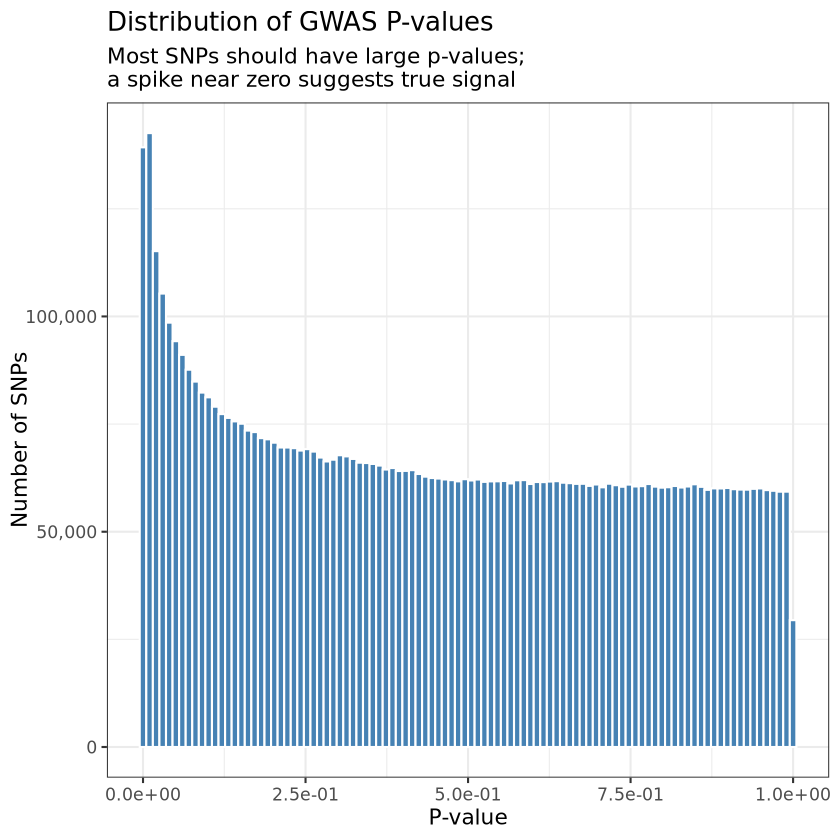

In [10]:
p1 <- ggplot(sumstats_qc, aes(x = P)) +
  geom_histogram(bins = 100, fill = "#4682B4", colour = "white") +
  scale_x_continuous(labels = label_scientific()) +
  scale_y_continuous(labels = label_comma()) +
  labs(
    title = "Distribution of GWAS P-values",
    subtitle = "Most SNPs should have large p-values;\na spike near zero suggests true signal",
    x = "P-value",
    y = "Number of SNPs"
  ) +
  theme_bw(base_size = 13)

ggsave(file.path(figures_dir, "1.1_pvalue_histogram.png"), p1, width = 8, height = 5, dpi = 150)
p1

In [11]:
png(file.path(figures_dir, "1.2_qqplot.png"), width = 700, height = 700, res = 120)
qq(sumstats_qc$P,
   main = "QQ Plot - ADHD GWAS",
   col = "#4682B4",
   cex = 0.4,
   xlim = c(0, 8),
   sub = sprintf("lambda = %.3f | lambda_1000 = %.3f", lambda_gc, lambda1000))
dev.off()
cat("Saved QQ plot to output/figures/1.2_qqplot.png\n")

pdf 
  2

Saved QQ plot to output/figures/1.2_qqplot.png


In [12]:
manhattan_data <- sumstats_qc %>%
  filter(CHR %in% 1:22) %>%
  select(CHR, BP, P, SNP)

png(file.path(figures_dir, "1.3_manhattan.png"), width = 1400, height = 600, res = 120)
manhattan(
  manhattan_data,
  chr = "CHR",
  bp = "BP",
  p = "P",
  snp = "SNP",
  main = "Manhattan Plot - ADHD GWAS 2023",
  col = c("#4682B4", "#B0C4DE"),
  suggestiveline = 1e-5,
  genomewideline = 5e-8,
  cex = 0.3,
  cex.axis = 0.8
)
dev.off()
cat("Saved Manhattan plot to output/figures/1.3_manhattan.png\n")

pdf 
  2

Saved Manhattan plot to output/figures/1.3_manhattan.png


Warning message:
“Removed 1718 rows containing non-finite outside the scale range
(`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”
Warning message:
“Removed 1718 rows containing non-finite outside the scale range
(`stat_bin()`).”
Warning message:
“Removed 2 rows containing missing values or values outside the scale range
(`geom_bar()`).”


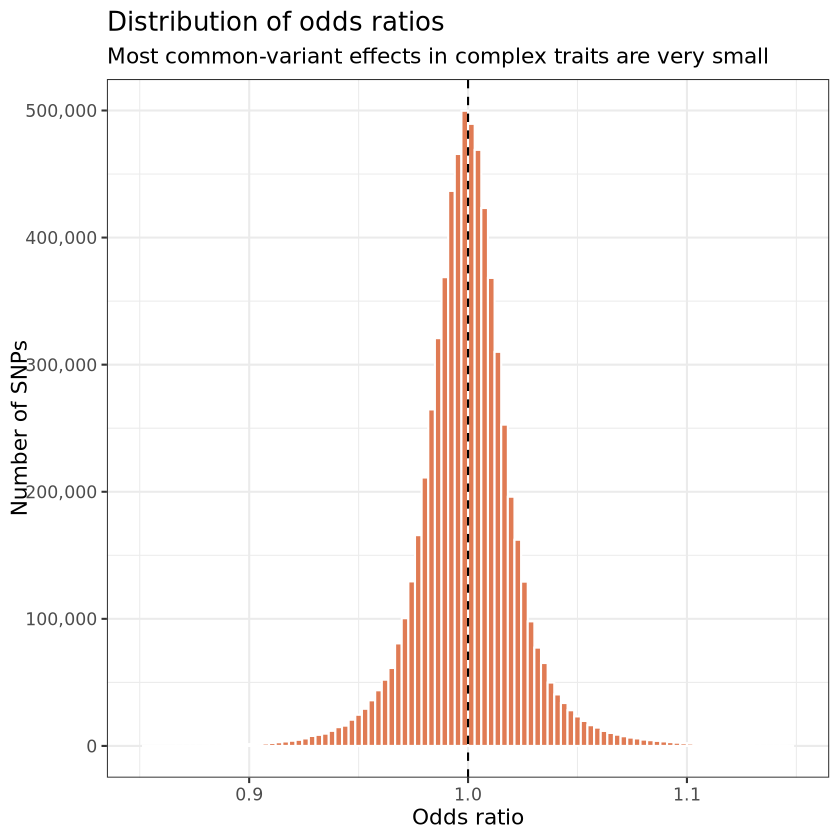

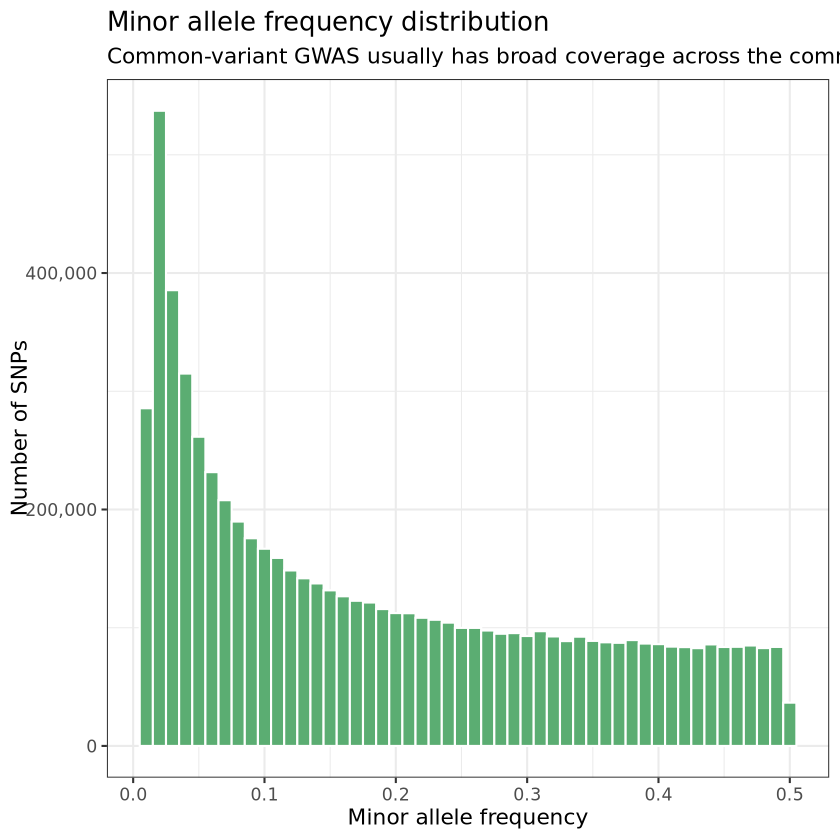

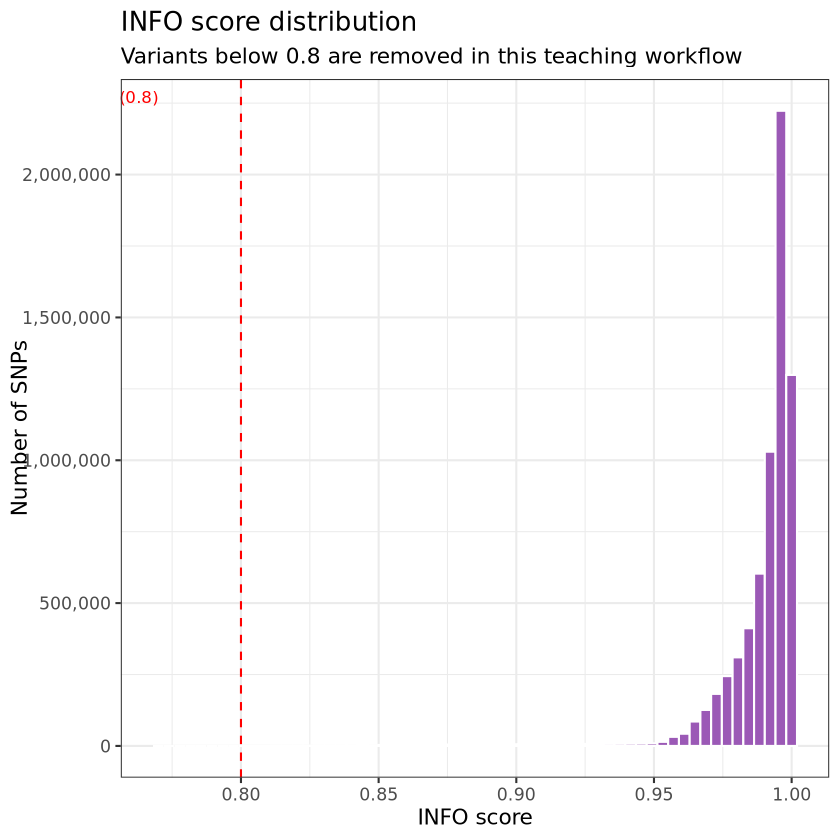

In [13]:
p4 <- ggplot(sumstats_qc, aes(x = OR)) +
  geom_histogram(bins = 100, fill = "#E07B54", colour = "white") +
  geom_vline(xintercept = 1, linetype = "dashed") +
  scale_x_continuous(limits = c(0.85, 1.15)) +
  scale_y_continuous(labels = label_comma()) +
  labs(
    title = "Distribution of odds ratios",
    subtitle = "Most common-variant effects in complex traits are very small",
    x = "Odds ratio",
    y = "Number of SNPs"
  ) +
  theme_bw(base_size = 13)

p5 <- ggplot(sumstats_qc, aes(x = MAF)) +
  geom_histogram(bins = 50, fill = "#5BAD72", colour = "white") +
  scale_y_continuous(labels = label_comma()) +
  labs(
    title = "Minor allele frequency distribution",
    subtitle = "Common-variant GWAS usually has broad coverage across the common-frequency range",
    x = "Minor allele frequency",
    y = "Number of SNPs"
  ) +
  theme_bw(base_size = 13)

p6 <- sumstats %>%
  filter(INFO <= 1) %>%
  ggplot(aes(x = INFO)) +
  geom_histogram(bins = 60, fill = "#9B59B6", colour = "white") +
  geom_vline(xintercept = 0.8, linetype = "dashed", colour = "red") +
  annotate("text", x = 0.77, y = Inf, label = "QC cut-off (0.8)", vjust = 2, hjust = 1, colour = "red", size = 3.5) +
  scale_y_continuous(labels = label_comma()) +
  labs(
    title = "INFO score distribution",
    subtitle = "Variants below 0.8 are removed in this teaching workflow",
    x = "INFO score",
    y = "Number of SNPs"
  ) +
  theme_bw(base_size = 13)

ggsave(file.path(figures_dir, "1.4_or_distribution.png"), p4, width = 8, height = 5, dpi = 150)
ggsave(file.path(figures_dir, "1.5_maf_distribution.png"), p5, width = 8, height = 5, dpi = 150)
ggsave(file.path(figures_dir, "1.6_info_distribution.png"), p6, width = 8, height = 5, dpi = 150)

p4
p5
p6

# Wrap-up

At this point you have an explored and lightly QC-filtered summary-statistics dataset. The next notebook converts these SNP-level results into the two MAGMA input files needed for annotation and gene analysis.

::: {.callout-tip}
## Reflection prompts
1. Which of the generated plots would you include in a short QC report, and why?
2. If lambda were much larger, what additional checks would you perform before trusting the signal?
3. What information is still missing if your goal is biological interpretation rather than variant discovery?
:::

In [14]:
summary_table <- tibble(
  metric = c("Total SNPs", "After QC", "Cases", "Controls", "Genome-wide significant SNPs", "lambda_GC", "lambda_1000"),
  value = c(nrow(sumstats), nrow(sumstats_qc), n_cases, n_controls, nrow(hits), lambda_gc, lambda1000)
)

summary_table

metric,value
<chr>,<dbl>
Total SNPs,6.774224e+06
After QC,6.774125e+06
Cases,3.869100e+04
Controls,1.868430e+05
Genome-wide significant SNPs,1.428000e+03
lambda_GC,1.321622e+00
lambda_1000,1.001426e+00
